# NGC 4151 Time-Cut Source Injection

This notebook injects an updated NGC 4151 spectrum with `SourceInjector` using only the orientation intervals where NGC 4151 is inside a chosen field-of-view cut. The output is a binned `histpy.Histogram` in Compton data space, not an unbinned event list.

The workflow is:

1. Define the updated NGC 4151 CPL+PL spectrum.
2. Build a GTI from the spacecraft pointing history for `off-axis <= max_offaxis`, optionally excluding Earth occultation.
3. Apply that GTI to the orientation file.
4. Inject NGC 4151 with the time-cut orientation.
5. Save and inspect the binned time-cut source histogram.


In [3]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.time import Time
from histpy import Histogram
from threeML import Cutoff_powerlaw, Powerlaw

from cosipy import SourceInjector
from cosipy.event_selection import GoodTimeInterval
from cosipy.spacecraftfile import SpacecraftHistory

%matplotlib inline

## Input Files

Edit these paths if you want to use a different response, orientation, or comparison file. The old NGC 4151 unbinned file is used only to define the same three-month time range as the existing NGC 4151 simulation.

In [4]:
response_path = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"
)

orientation_file = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori"
)

old_ngc_unbinned_file = Path(
    "/Users/parshadkp/Software/COSI_Data/DC4_Files/NGC_4151__3months_unbinned_data_filtered_with_SAAcut.fits"
)

existing_updated_binned_file = Path(
    "/Users/parshadkp/Software/COSI_Data/AGN_Data/GammaRay/Paper_Models/NGC_4151_ec200_DC3_COSI_cpl_pl.hdf5"
)

output_file = Path(
    "/Users/parshadkp/Software/COSI_Data/DC4_Files/NGC_4151_ec200_DC4_COSI_cpl_pl_fluxNTH_0p15_time_cut_in_fov.hdf5"
)

source_name = "NGC 4151"
source_coord = SkyCoord(l=155.07 * u.deg, b=75.06 * u.deg, frame="galactic")

max_offaxis = 60 * u.deg
earth_occ = True

## Updated Spectrum

The spectrum below is the cutoff power law plus high-energy power law model supplied for the updated NGC 4151 injection. `exposure_multiplier` is left explicit because it rescales the injected flux normalization.

In [5]:
exposure_multiplier = 1.0

K_inj = (0.15 * exposure_multiplier) / u.cm / u.cm / u.s / u.keV
piv_inj = 1.0 * u.keV
xc_inj = 200.0 * u.keV
index_inj = -1.75

spectrum_inj_ec200 = Cutoff_powerlaw()

spectrum_inj_ec200.K.value = K_inj.value
spectrum_inj_ec200.piv.value = piv_inj.value
spectrum_inj_ec200.xc.value = xc_inj.value
spectrum_inj_ec200.index.value = index_inj

spectrum_inj_ec200.K.unit = K_inj.unit
spectrum_inj_ec200.piv.unit = piv_inj.unit
spectrum_inj_ec200.xc.unit = xc_inj.unit

K_inj = 0.15 * spectrum_inj_ec200.evaluate_at(200) / u.cm / u.cm / u.s / u.keV
piv_inj = 200.0 * u.keV
index_inj = -3.8

spectrum_inj_ec200_PL = Powerlaw()

spectrum_inj_ec200_PL.K.value = K_inj.value
spectrum_inj_ec200_PL.piv.value = piv_inj.value
spectrum_inj_ec200_PL.index.value = index_inj

spectrum_inj_ec200_PL.K.unit = K_inj.unit
spectrum_inj_ec200_PL.piv.unit = piv_inj.unit

spectrum_inj_ec200_total = spectrum_inj_ec200 + spectrum_inj_ec200_PL

print(spectrum_inj_ec200_total)

  * description: (Cutoff_powerlaw{1} + Powerlaw{2})
  * formula: (no latex formula available)
  * parameters:
    * K_1:
      * value: 0.15
      * desc: Normalization (differential flux at the pivot value)
      * min_value: 1.0e-30
      * max_value: 1000.0
      * unit: keV-1 s-1 cm-2
      * is_normalization: true
      * delta: 0.1
      * free: true
    * piv_1:
      * value: 1.0
      * desc: Pivot value
      * min_value: null
      * max_value: null
      * unit: keV
      * is_normalization: false
      * delta: 0.1
      * free: false
    * index_1:
      * value: -1.75
      * desc: Photon index
      * min_value: -10.0
      * max_value: 10.0
      * unit: ''
      * is_normalization: false
      * delta: 0.2
      * free: true
    * xc_1:
      * value: 200.00000000000003
      * desc: Cutoff energy
      * min_value: 1.0
      * max_value: null
      * unit: keV
      * is_normalization: false
      * delta: 1.0
      * free: true
    * K_2:
      * value: 7.7818981744

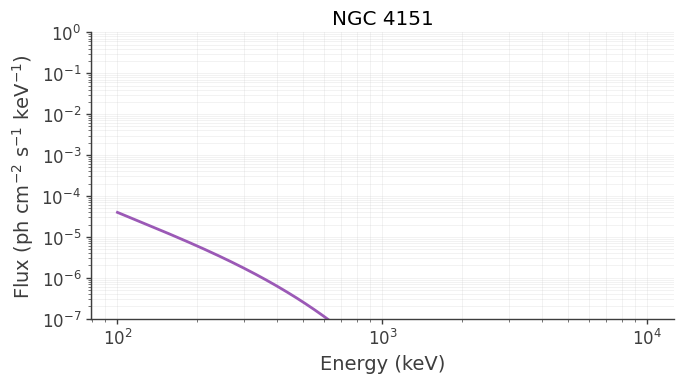

In [8]:
energy_grid = np.geomspace(100, 10000, 300) * u.keV
flux_grid = spectrum_inj_ec200_total(energy_grid.value)

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(energy_grid.to_value(u.keV), flux_grid)
ax.set_xlabel("Energy (keV)")
ax.set_ylabel(r"Flux (ph cm$^{-2}$ s$^{-1}$ keV$^{-1}$)")
ax.set_title(source_name)
ax.grid(alpha=0.3, which="both")
ax.set_ylim(1e-7, 1)
fig.tight_layout()

## Build the FOV Time Cut

The old source-only NGC 4151 event file is used here just to read the start and stop times of the same data span. The events themselves are not used for the new injection.

In [ ]:
with fits.open(old_ngc_unbinned_file, memmap=True) as hdul:
    old_time_tags = hdul[1].data["TimeTags"]
    event_tstart = Time(float(np.min(old_time_tags)), format="unix", scale="utc")
    event_tstop = Time(float(np.max(old_time_tags)), format="unix", scale="utc")

ori = SpacecraftHistory.open(
    orientation_file,
    tstart=event_tstart,
    tstop=event_tstop,
).select_interval(event_tstart, event_tstop)

source_gti = GoodTimeInterval.from_pointing_cut(
    source_coord,
    ori,
    max_offaxis,
    earth_occ=earth_occ,
)

ori_cut = ori.apply_gti(source_gti)

total_livetime = ori.cumulative_livetime().to_value(u.s)
cut_livetime = ori_cut.cumulative_livetime().to_value(u.s)

print(f"Event time range: {event_tstart.isot} to {event_tstop.isot}")
print(f"Orientation pointings before cut: {len(ori.obstime):,}")
print(f"GTI intervals: {len(source_gti):,}")
print(f"Orientation pointings after cut: {len(ori_cut.obstime):,}")
print(f"Total livetime: {total_livetime:,.1f} s")
print(f"Time-cut livetime: {cut_livetime:,.1f} s")
print(f"Livetime fraction: {cut_livetime / total_livetime:.4f}")

In [ ]:
source_sc = ori.get_target_in_sc_frame(source_coord)
offaxis = (np.pi / 2 * u.rad - source_sc.lat).to_value(u.deg)
time_hours = (ori.obstime.unix - ori.obstime.unix[0]) / 3600

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(time_hours, offaxis, lw=1)
ax.axhline(max_offaxis.to_value(u.deg), color="tab:red", ls="--", label="FOV cut")
ax.set_xlabel("Time since first pointing (hr)")
ax.set_ylabel("Source off-axis angle (deg)")
ax.set_ylim(0, 180)
ax.set_xlim(0, min(100, time_hours[-1]))
ax.legend()
fig.tight_layout()

## Inject the Time-Cut Source

This is the expensive cell. It opens the full detector response, builds a scattering map from the time-cut orientation, folds the updated spectrum through the response, and writes a binned histogram.

In [ ]:
%%time

injector = SourceInjector(
    response_path=response_path,
    response_frame="spacecraftframe",
)

output_file.parent.mkdir(parents=True, exist_ok=True)

ngc4151_time_cut = injector.inject_point_source(
    spectrum=spectrum_inj_ec200_total,
    coordinate=source_coord,
    orientation=ori_cut,
    source_name=source_name,
    make_spectrum_plot=True,
    make_PsiChi_plot=False,
    data_save_path=output_file,
    project_axes=["Em", "Phi", "PsiChi"],
    earth_occ=earth_occ,
)

print(f"Wrote: {output_file}")

## Inspect the Output

The saved file is suitable for binned analyses or for binned mock replacement, as long as the histogram axes match the other binned components.

In [ ]:
def histogram_total(hist):
    total = np.sum(hist.contents)
    return float(total.value if hasattr(total, "value") else total)


injected = Histogram.open(output_file)

print(injected)
print(f"Total injected counts: {histogram_total(injected):,.3f}")

ax, plot = injected.project("Em").draw(label="Updated NGC 4151, time cut", color="tab:red")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Measured energy (keV)")
ax.set_ylabel("Counts")
ax.legend()
ax.grid(alpha=0.3, which="both")

## Optional: Compare to the Existing Updated Binned File

This comparison is useful for checking axis compatibility and count scaling. If the existing file was generated with the full three-month orientation rather than the FOV time cut, the total counts are not expected to match.

In [ ]:
if existing_updated_binned_file.exists():
    existing_updated = Histogram.open(existing_updated_binned_file)

    print("Injected axes:", injected.axes.labels)
    print("Existing axes:", existing_updated.axes.labels)
    print(f"Injected total counts: {histogram_total(injected):,.3f}")
    print(f"Existing total counts: {histogram_total(existing_updated):,.3f}")

    ax, plot = existing_updated.project("Em").draw(
        label="Existing updated NGC 4151", color="black"
    )
    injected.project("Em").draw(
        ax=ax,
        label="Updated NGC 4151, time cut",
        color="tab:red",
        linestyle="dotted",
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Measured energy (keV)")
    ax.set_ylabel("Counts")
    ax.legend()
    ax.grid(alpha=0.3, which="both")
else:
    print(f"No comparison file found: {existing_updated_binned_file}")

## Optional: Binned Mock Replacement Pattern

Once you have a time-cut mixed mock histogram, a time-cut old NGC 4151 histogram, and this time-cut updated NGC 4151 histogram on identical axes, the replacement is simply:

```python
mock_replaced = mock_time_cut - old_ngc_time_cut + injected
mock_replaced.write("mock_with_updated_NGC4151_time_cut.hdf5", overwrite=True)
```

This operation is a binned replacement. It does not create an unbinned FITS event list.